# Loan Default Risk with Business Cost Optimization (Home Credit)

## Problem Statement
Lenders face a trade-off: reject too many applicants and you lose good
business; approve too many risky applicants and you absorb defaults, which
are typically far more costly than a missed approval. This notebook builds
a binary classifier to predict loan default risk, then goes a step further
by optimizing the decision threshold based on actual business costs rather
than defaulting to a generic 0.5 cutoff.

## Objective
1. Clean and preprocess the Home Credit application dataset
2. Train binary classification models (Logistic Regression, CatBoost)
3. Define business cost values for false positives and false negatives
4. Adjust the decision threshold to minimize total business cost

## 1. Dataset Description & Loading

**Source:** Home Credit Default Risk Dataset (Kaggle competition data)
**Rows:** ~215,000 loan applications, 102 columns
**Target:** `TARGET` — 1 = client had difficulty repaying (defaulted), 0 = repaid on time

The dataset is loaded directly from a public mirror inside this notebook —
no manual download needed. It includes socio-demographic info, income,
loan details, and external credit bureau scores for each applicant.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import zipfile
import io

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, roc_curve,
                              classification_report)
from catboost import CatBoostClassifier

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

url = 'https://raw.githubusercontent.com/sultanbeishenkulov/home-credit-default-risk/main/train.csv.zip'
resp = requests.get(url)
with zipfile.ZipFile(io.BytesIO(resp.content)) as z:
    with z.open('train.csv') as f:
        df = pd.read_csv(f, low_memory=False)

print("Shape:", df.shape)
df.head()

Shape: (215257, 102)


,ID,NAME_CONTRACT_TYPE,GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,EXT_SOURCE_4,TARGET
0,160132,Cash loans,F,N,Y,0,427500.0,1288350.0,37800.0,1125000.0,...,0,0,0.0,0.0,1.0,0.0,0.0,5.0,0.242982,0
1,233132,Cash loans,M,Y,Y,0,180000.0,848745.0,40963.5,675000.0,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0.115508,0
2,307771,Cash loans,M,Y,Y,1,112500.0,385164.0,19795.5,292500.0,...,0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.393106,0
3,376452,Cash loans,F,N,Y,0,540000.0,1433520.0,60867.0,1237500.0,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.455985,0
4,405403,Cash loans,M,Y,Y,0,76500.0,900000.0,26316.0,900000.0,...,0,0,0.0,0.0,0.0,3.0,0.0,2.0,0.141508,0


TARGET
0    197809
1     17448
Name: count, dtype: int64
TARGET
0    0.919
1    0.081
Name: proportion, dtype: float64


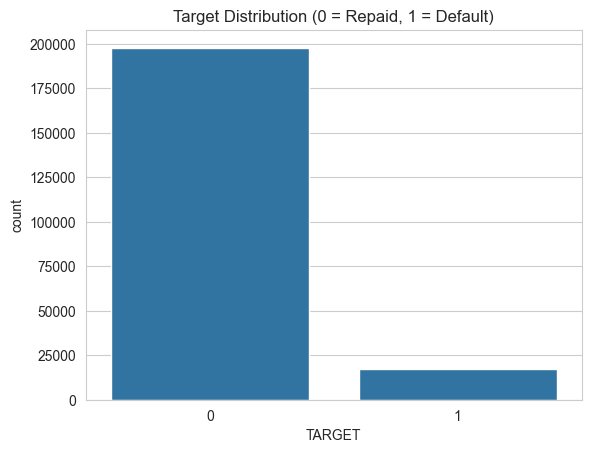

In [2]:
print(df['TARGET'].value_counts())
print(df['TARGET'].value_counts(normalize=True).round(3))

sns.countplot(x='TARGET', data=df)
plt.title('Target Distribution (0 = Repaid, 1 = Default)')
plt.show()

The target is **highly imbalanced**: only ~8% of loans in the sample
defaulted. This is realistic for lending data (most loans are repaid) but
means accuracy is a poor evaluation metric — a model predicting "no
default" for everyone would already be ~92% "accurate" while being
completely useless. We use ROC-AUC and business-cost-based evaluation
instead.

## 2. Data Cleaning & Preprocessing

Steps:
1. Drop columns with more than 40% missing values (too sparse to reliably impute)
2. Drop the ID column (not predictive)
3. Impute remaining missing numeric values with the median, categorical with `"missing"`
4. One-Hot Encode categorical features

In [3]:
missing_frac = df.isnull().mean().sort_values(ascending=False)
missing_frac.head(15)

NONLIVINGAPARTMENTS_MODE    0.693696
NONLIVINGAPARTMENTS_AVG     0.693696
NONLIVINGAPARTMENTS_MEDI    0.693696
FLOORSMIN_AVG               0.677613
FLOORSMIN_MEDI              0.677613
FLOORSMIN_MODE              0.677613
YEARS_BUILD_AVG             0.664160
YEARS_BUILD_MODE            0.664160
YEARS_BUILD_MEDI            0.664160
OWN_CAR_AGE                 0.659454
EXT_SOURCE_1                0.563118
NONLIVINGAREA_MODE          0.551689
NONLIVINGAREA_AVG           0.551689
NONLIVINGAREA_MEDI          0.551689
ELEVATORS_MODE              0.532842
dtype: float64

In [4]:
cols_to_drop = missing_frac[missing_frac > 0.4].index.tolist()
df_clean = df.drop(columns=cols_to_drop)
df_clean = df_clean.drop(columns=['ID'])

print(f"Dropped {len(cols_to_drop)} columns with >40% missing values")
print("Shape after cleaning:", df_clean.shape)

Dropped 32 columns with >40% missing values
Shape after cleaning: (215257, 69)


In [5]:
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
num_cols = [c for c in df_clean.select_dtypes(include=['int64', 'float64']).columns if c != 'TARGET']

print(f"{len(cat_cols)} categorical columns, {len(num_cols)} numeric columns")

for c in num_cols:
    df_clean[c] = df_clean[c].fillna(df_clean[c].median())
for c in cat_cols:
    df_clean[c] = df_clean[c].fillna('missing')

print("Remaining missing values:", df_clean.isnull().sum().sum())

C:\Users\FIREFLY LAPTOP'S\AppData\Local\Temp\ipykernel_18580\1205795520.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_clean.select_dtypes(include='object').columns.tolist()


12 categorical columns, 56 numeric columns
Remaining missing values: 0


In [6]:
df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)
print("Encoded shape:", df_encoded.shape)

Encoded shape: (215257, 171)


## 3. Exploratory Data Analysis

A quick look at how default rate relates to a few key applicant
characteristics.

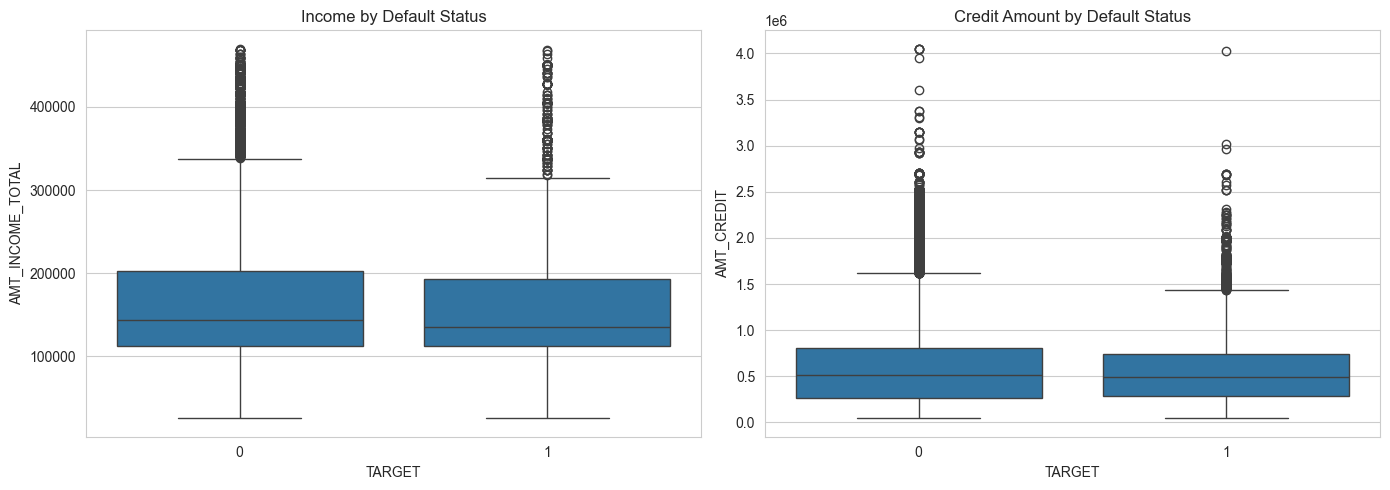

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='TARGET', y='AMT_INCOME_TOTAL', data=df_clean[df_clean['AMT_INCOME_TOTAL'] < df_clean['AMT_INCOME_TOTAL'].quantile(0.99)], ax=axes[0])
axes[0].set_title('Income by Default Status')

sns.boxplot(x='TARGET', y='AMT_CREDIT', data=df_clean, ax=axes[1])
axes[1].set_title('Credit Amount by Default Status')

plt.tight_layout()
plt.show()

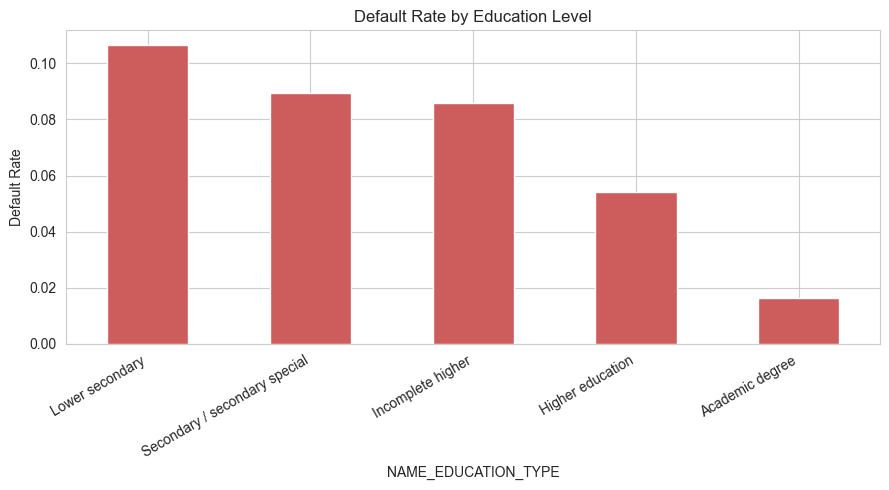

In [8]:
default_by_education = df_clean.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 5))
default_by_education.plot(kind='bar', color='indianred', ax=ax)
ax.set_title('Default Rate by Education Level')
ax.set_ylabel('Default Rate')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Applicants with lower education levels show a noticeably higher default
rate than those with higher education — a pattern the model should pick
up on automatically through the encoded education features.

## 4. Train/Test Split

In [9]:
X = df_encoded.drop(columns=['TARGET'])
y = df_encoded['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (172205, 170) | Test: (43052, 170)


## 5. Model 1 — Logistic Regression (Baseline)

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
logreg.fit(X_train_scaled, y_train)

proba_lr = logreg.predict_proba(X_test_scaled)[:, 1]
pred_lr = (proba_lr >= 0.5).astype(int)

print(f"Logistic Regression — ROC-AUC: {roc_auc_score(y_test, proba_lr):.4f}")

Logistic Regression — ROC-AUC: 0.7178


## 6. Model 2 — CatBoost

CatBoost handles categorical structure and non-linear relationships well,
and typically outperforms logistic regression on tabular data like this
without heavy tuning.

In [11]:
cat_model = CatBoostClassifier(
    iterations=300, depth=6, learning_rate=0.1,
    auto_class_weights='Balanced', random_state=42, verbose=False
)
cat_model.fit(X_train, y_train)

proba_cat = cat_model.predict_proba(X_test)[:, 1]
pred_cat = (proba_cat >= 0.5).astype(int)

print(f"CatBoost — ROC-AUC: {roc_auc_score(y_test, proba_cat):.4f}")

CatBoost — ROC-AUC: 0.7303


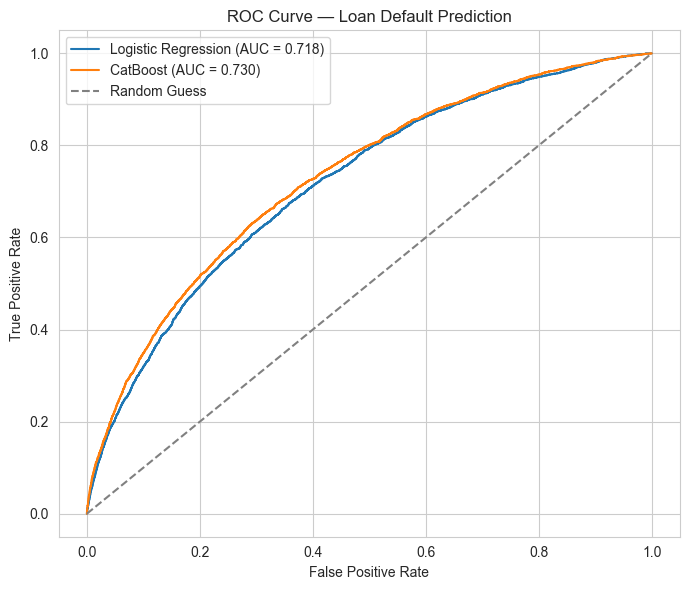

In [12]:
fig, ax = plt.subplots(figsize=(7, 6))

for name, proba in [('Logistic Regression', proba_lr), ('CatBoost', proba_cat)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_score = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})')

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Loan Default Prediction')
ax.legend()
plt.tight_layout()
plt.show()

CatBoost outperforms the logistic regression baseline, as expected for
tabular data with non-linear feature interactions. We proceed with
**CatBoost** for the business cost optimization step below.

## 7. Business Cost Definition

In loan default prediction, the two error types have very different
real-world costs:

- **False Positive** (predicted default, but customer would have repaid):
  the bank loses out on a *good* customer — lost interest/profit from a
  loan that would have performed fine. We assign this a cost of **$1,000**
  (approximate lost profit from a rejected good applicant).
- **False Negative** (predicted repay, but customer actually defaults):
  the bank approves a loan that is never repaid — a direct loss of
  principal and collection costs. We assign this a cost of **$15,000**
  (far larger, reflecting a real, unrecovered loss).

This 15:1 cost ratio reflects a common real-world pattern in lending: a
missed default is usually far more expensive than a missed approval. The
default 0.5 classification threshold does **not** account for this
asymmetry — it treats both error types as equally costly, which is rarely
true in a business setting.

In [13]:
cost_fp = 1000    # cost of wrongly rejecting a good customer
cost_fn = 15000   # cost of approving a loan that defaults

thresholds = np.arange(0.05, 0.95, 0.01)
total_costs = []

for t in thresholds:
    preds = (proba_cat >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    total_costs.append(fp * cost_fp + fn * cost_fn)

total_costs = np.array(total_costs)
best_idx = np.argmin(total_costs)
best_threshold = thresholds[best_idx]

print(f"Optimal threshold: {best_threshold:.2f}")
print(f"Minimum total cost: ${total_costs[best_idx]:,.0f}")

default_idx = np.argmin(np.abs(thresholds - 0.5))
print(f"Cost at default 0.5 threshold: ${total_costs[default_idx]:,.0f}")
print(f"Savings from optimization: ${total_costs[default_idx] - total_costs[best_idx]:,.0f}")

Optimal threshold: 0.43
Minimum total cost: $30,014,000
Cost at default 0.5 threshold: $30,915,000
Savings from optimization: $901,000


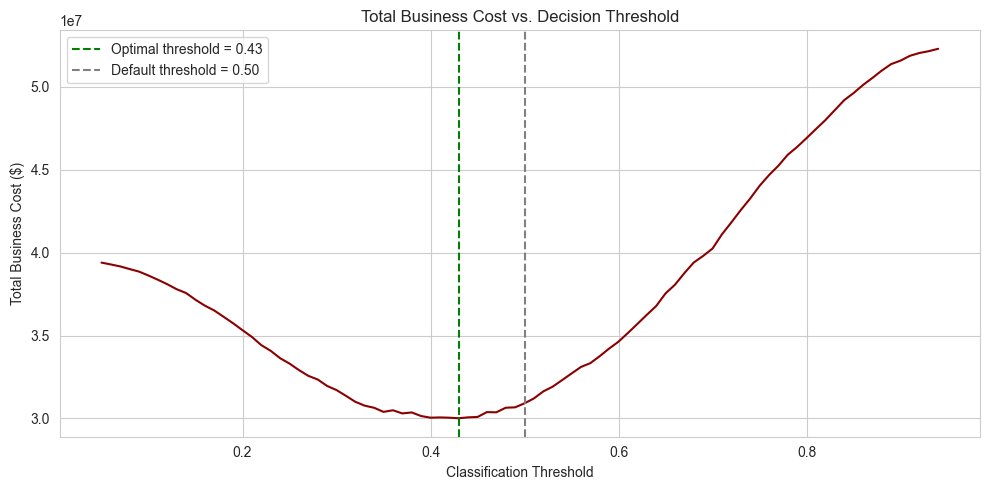

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, total_costs, color='darkred')
ax.axvline(best_threshold, color='green', linestyle='--', label=f'Optimal threshold = {best_threshold:.2f}')
ax.axvline(0.5, color='gray', linestyle='--', label='Default threshold = 0.50')
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Total Business Cost ($)')
ax.set_title('Total Business Cost vs. Decision Threshold')
ax.legend()
plt.tight_layout()
plt.show()

The cost curve shows a clear minimum below the default 0.5 threshold —
because false negatives (missed defaults) are far more expensive than
false positives here, the optimal strategy is to be **more conservative**,
flagging more applicants as risky than a plain accuracy-optimized model
would.

In [15]:
pred_default = (proba_cat >= 0.5).astype(int)
pred_optimal = (proba_cat >= best_threshold).astype(int)

comparison = pd.DataFrame({
    'Threshold': ['0.50 (default)', f'{best_threshold:.2f} (cost-optimal)'],
    'Precision': [precision_score(y_test, pred_default), precision_score(y_test, pred_optimal)],
    'Recall': [recall_score(y_test, pred_default), recall_score(y_test, pred_optimal)],
    'F1-Score': [f1_score(y_test, pred_default), f1_score(y_test, pred_optimal)],
    'Total Cost ($)': [total_costs[default_idx], total_costs[best_idx]]
})
comparison

,Threshold,Precision,Recall,F1-Score,Total Cost ($)
0,0.50 (default),0.159152,0.632092,0.254279,30915000
1,0.43 (cost-optimal),0.136129,0.739542,0.229933,30014000


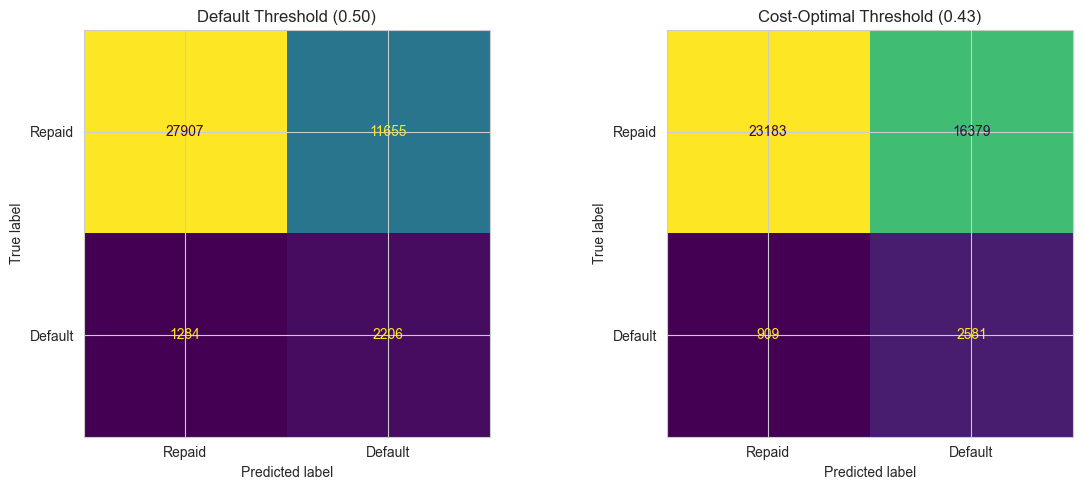

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(confusion_matrix(y_test, pred_default), display_labels=['Repaid', 'Default']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Default Threshold (0.50)')

ConfusionMatrixDisplay(confusion_matrix(y_test, pred_optimal), display_labels=['Repaid', 'Default']).plot(ax=axes[1], colorbar=False)
axes[1].set_title(f'Cost-Optimal Threshold ({best_threshold:.2f})')

plt.tight_layout()
plt.show()

Shifting the threshold **catches more true defaults (higher recall)** at
the cost of flagging more good customers as risky (lower precision) — but
since a missed default is far more expensive than a false rejection under
our defined costs, this trade-off reduces total business cost overall.

## 8. Feature Importance

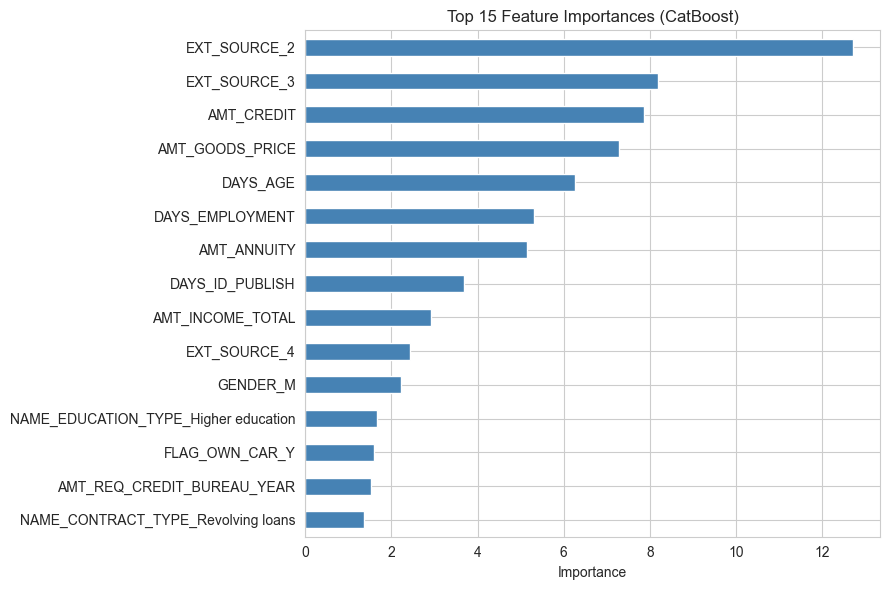

In [17]:
importances = cat_model.get_feature_importance()
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
feat_imp.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 15 Feature Importances (CatBoost)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

**EXT_SOURCE_2/3/4** (normalized external credit bureau scores) dominate
feature importance — unsurprising, since these are purpose-built
creditworthiness indicators from external sources. Loan and income amounts
(`AMT_GOODS_PRICE`, `AMT_CREDIT`, `AMT_ANNUITY`, `AMT_INCOME_TOTAL`) and
applicant age/tenure (`DAYS_AGE`, `DAYS_EMPLOYMENT`) round out the top
predictors — all intuitive drivers of repayment ability.